In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import HTML
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay  

from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay  

from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [3]:
df.shape

(10000, 15)

In [4]:
df.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [5]:
df['Medical Condition'].unique()

array(['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension',
       'Cancer'], dtype=object)

In [6]:
df["Blood Type"].unique()

array(['O-', 'O+', 'B-', 'AB+', 'A+', 'AB-', 'A-', 'B+'], dtype=object)

In [7]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [8]:
df["Medication"].unique()

array(['Aspirin', 'Lipitor', 'Penicillin', 'Paracetamol', 'Ibuprofen'],
      dtype=object)

In [9]:
df["Test Results"].unique()

array(['Inconclusive', 'Normal', 'Abnormal'], dtype=object)

In [10]:
df["Admission Type"].unique()

array(['Elective', 'Emergency', 'Urgent'], dtype=object)

In [11]:
df["Insurance Provider"].unique()

array(['Medicare', 'UnitedHealthcare', 'Aetna', 'Cigna', 'Blue Cross'],
      dtype=object)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [13]:
df.corr()

,Age,Billing Amount,Room Number
Age,1.000000,-0.009483,-0.005371
Billing Amount,-0.009483,1.000000,-0.006160
Room Number,-0.005371,-0.006160,1.000000


## Exploratory Data Analysis

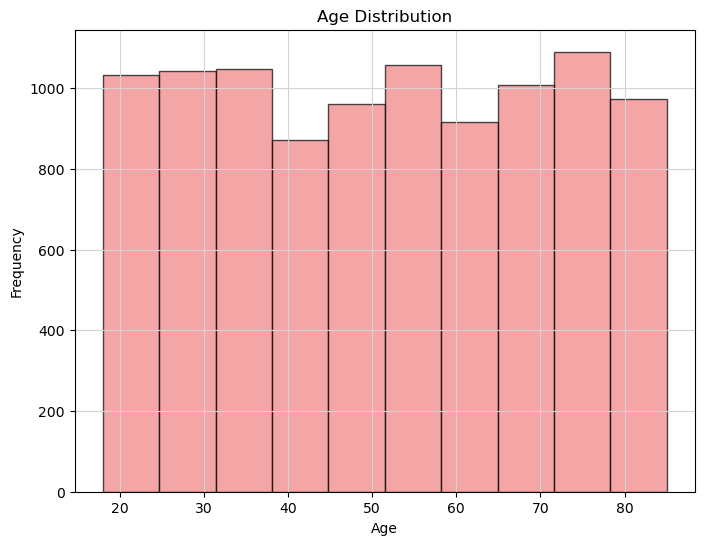

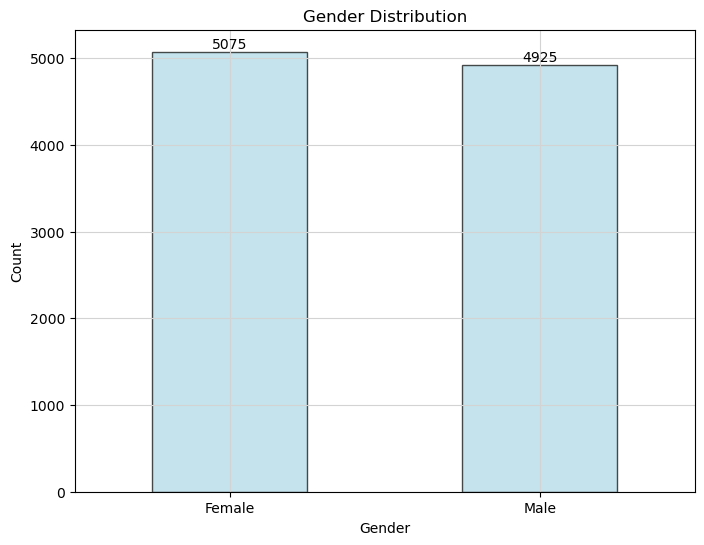

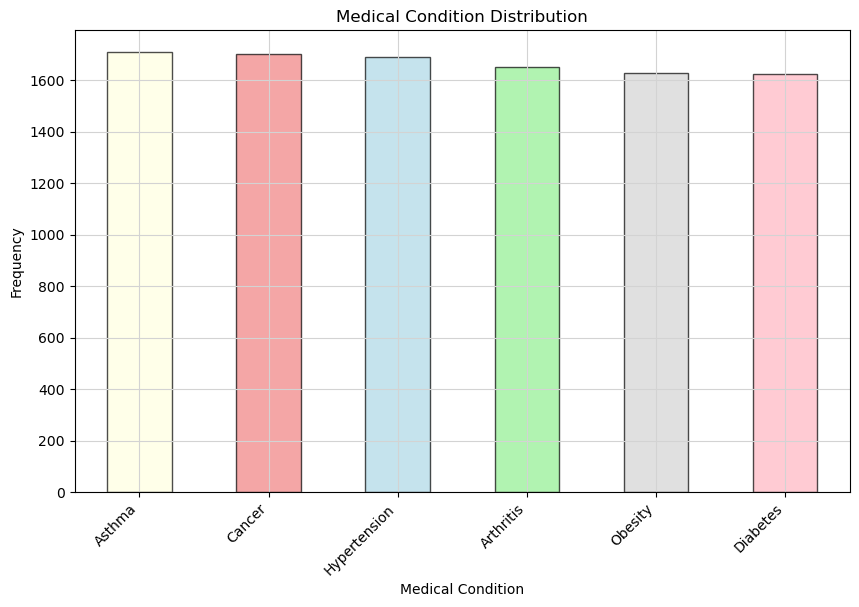

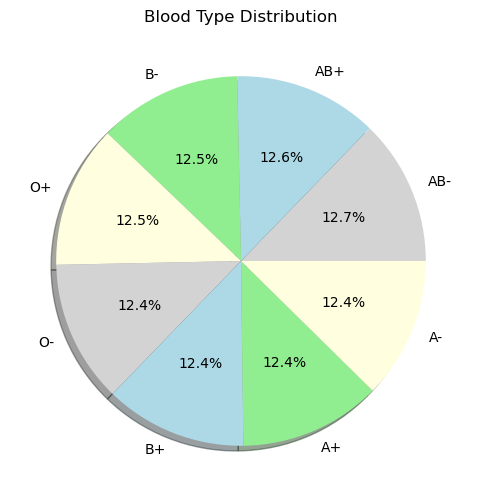

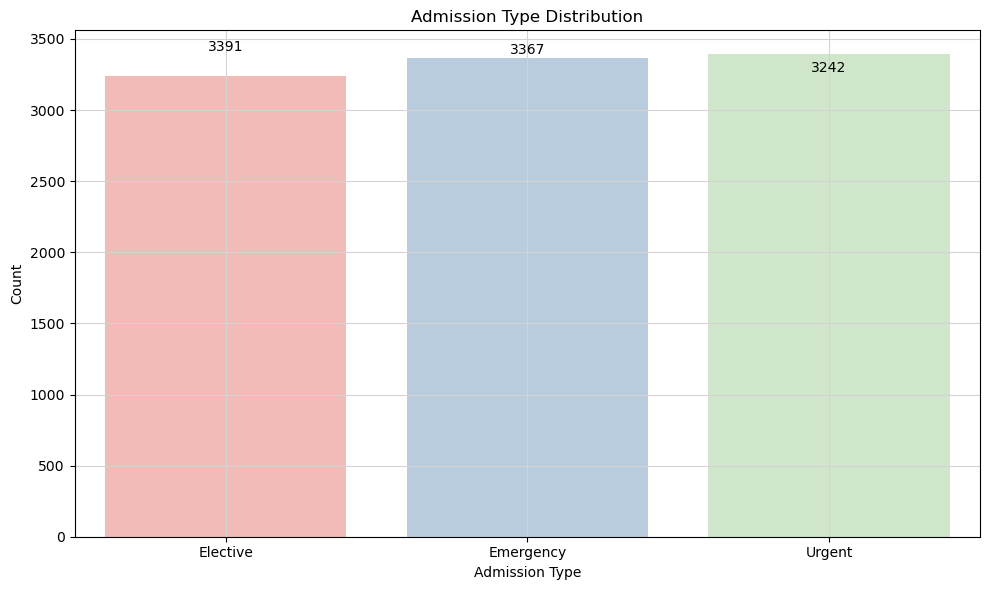

In [14]:
# 1. Histogram of Age distribution
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(color='lightgrey')
plt.show()

# 2. Bar plot of Gender distribution
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
bars = gender_counts.plot(kind='bar', color='lightblue', edgecolor='black', alpha=0.7)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(color='lightgrey')
for i, v in enumerate(gender_counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.show()


# 3. Bar plot of Medical Condition distribution
plt.figure(figsize=(10, 6))
colors = ['lightyellow', 'lightcoral', 'lightblue', 'lightgreen', 'lightgrey', 'lightpink']
medical_condition_counts = df['Medical Condition'].value_counts()
medical_condition_counts_sorted = medical_condition_counts.sort_values(ascending=False)

medical_condition_counts_sorted.plot(kind='bar', color=colors, edgecolor='black', alpha=0.7)
plt.title('Medical Condition Distribution')
plt.xlabel('Medical Condition')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(color='lightgrey')
plt.show()

# 4. Pie chart of Blood Type distribution
plt.figure(figsize=(8, 6))
df['Blood Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgrey', 'lightblue', 'lightgreen', 'lightyellow'], shadow=True)
plt.title('Blood Type Distribution')
plt.ylabel('')
plt.show()


# 5. Count plot for 'Admission Type'
plt.figure(figsize=(10, 6))
admission_type_counts = df['Admission Type'].value_counts()
sns.countplot(x='Admission Type', data=df, palette='Pastel1')

# Add data point values on top of each bar
for i, count in enumerate(admission_type_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.title('Admission Type Distribution')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.grid(color='lightgrey')

plt.tight_layout()
plt.show()


## Preprocessing the Data 

##### Dropping the insignificant columns

In [15]:
df2 = df.drop(columns = ["Name","Date of Admission", "Doctor","Hospital" , "Discharge Date", "Room Number"])
df2.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results
0,81,Female,O-,Diabetes,Medicare,37490.983364,Elective,Aspirin,Inconclusive
1,35,Male,O+,Asthma,UnitedHealthcare,47304.064845,Emergency,Lipitor,Normal
2,61,Male,B-,Obesity,Medicare,36874.896997,Emergency,Lipitor,Normal
3,49,Male,B-,Asthma,Medicare,23303.322092,Urgent,Penicillin,Abnormal
4,51,Male,O-,Arthritis,UnitedHealthcare,18086.344184,Urgent,Paracetamol,Normal


In [16]:
df2.describe()

,Age,Billing Amount
count,10000.000000,10000.000000
mean,51.452200,25516.806778
std,19.588974,14067.292709
min,18.000000,1000.180837
25%,35.000000,13506.523967
50%,52.000000,25258.112566
75%,68.000000,37733.913727
max,85.000000,49995.902283


In [17]:
numeric_feats = ["Age", "Billing Amount"]
categorical_feats = ["Medical Condition", "Blood Type", "Medication", "Test Results","Insurance Provider"]
binary_feats = ["Gender"]
ordinal_feats = ["Admission Type"]


In [18]:
ct = ColumnTransformer(
    [
        ("imputeandscale", make_pipeline(SimpleImputer(), StandardScaler()), numeric_feats),
        ("onehot", OneHotEncoder(sparse_output=False), categorical_feats),
        ("binonehot", OneHotEncoder(sparse_output=False, drop="if_binary"), binary_feats),
        ("ordinal", OrdinalEncoder(categories=[["Elective", "Urgent", "Emergency"]]), ordinal_feats),
    ]
)

In [19]:
ct

ColumnTransformer(transformers=[('imputeandscale',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Age', 'Billing Amount']),
                                ('onehot', OneHotEncoder(sparse_output=False),
                                 ['Medical Condition', 'Blood Type',
                                  'Medication', 'Test Results',
                                  'Insurance Provider']),
                                ('binonehot',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Gender']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['Elective',
                                                             'Urgent',
                                                             'Emergency']]),
                                 ['Admission Type'])])

In [20]:
df2_transformed = ct.fit_transform(df2)

df2_transformed

array([[ 1.50846482,  0.85124946,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.83991244,  1.54886572,  0.        , ...,  1.        ,
         1.        ,  2.        ],
       [ 0.48743123,  0.80745161,  0.        , ...,  0.        ,
         1.        ,  2.        ],
       ...,
       [ 0.13006947,  1.70918448,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.66161985, -0.01993817,  1.        , ...,  1.        ,
         1.        ,  1.        ],
       [-1.60568763,  0.83226707,  1.        , ...,  0.        ,
         1.        ,  2.        ]])

In [21]:
column_names = (
    numeric_feats  
    + ct.named_transformers_["onehot"].get_feature_names_out().tolist()
    + binary_feats
    + ordinal_feats
)
column_names

['Age',
 'Billing Amount',
 'Medical Condition_Arthritis',
 'Medical Condition_Asthma',
 'Medical Condition_Cancer',
 'Medical Condition_Diabetes',
 'Medical Condition_Hypertension',
 'Medical Condition_Obesity',
 'Blood Type_A+',
 'Blood Type_A-',
 'Blood Type_AB+',
 'Blood Type_AB-',
 'Blood Type_B+',
 'Blood Type_B-',
 'Blood Type_O+',
 'Blood Type_O-',
 'Medication_Aspirin',
 'Medication_Ibuprofen',
 'Medication_Lipitor',
 'Medication_Paracetamol',
 'Medication_Penicillin',
 'Test Results_Abnormal',
 'Test Results_Inconclusive',
 'Test Results_Normal',
 'Insurance Provider_Aetna',
 'Insurance Provider_Blue Cross',
 'Insurance Provider_Cigna',
 'Insurance Provider_Medicare',
 'Insurance Provider_UnitedHealthcare',
 'Gender',
 'Admission Type']

In [22]:
ct.named_transformers_

{'imputeandscale': Pipeline(steps=[('simpleimputer', SimpleImputer()),
                 ('standardscaler', StandardScaler())]),
 'onehot': OneHotEncoder(sparse_output=False),
 'binonehot': OneHotEncoder(drop='if_binary', sparse_output=False),
 'ordinal': OrdinalEncoder(categories=[['Elective', 'Urgent', 'Emergency']])}

In [23]:
df3 = pd.DataFrame(df2_transformed, columns= column_names)

df3.head()

,Age,Billing Amount,Medical Condition_Arthritis,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Blood Type_A+,Blood Type_A-,...,Test Results_Abnormal,Test Results_Inconclusive,Test Results_Normal,Insurance Provider_Aetna,Insurance Provider_Blue Cross,Insurance Provider_Cigna,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Gender,Admission Type
0,1.508465,0.851249,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.839912,1.548866,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
2,0.487431,0.807452,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
3,-0.125189,-0.157358,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,-0.023086,-0.528235,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


### Selecting the Target Variable and performing Test - train split

## Target : Test Results_Abnormal

In [24]:
X = df3.drop(columns=["Test Results_Abnormal"])


Y = df3["Test Results_Abnormal"]


X

Y

0       0.0
1       0.0
2       0.0
3       1.0
4       0.0
       ... 
9995    1.0
9996    0.0
9997    0.0
9998    0.0
9999    1.0
Name: Test Results_Abnormal, Length: 10000, dtype: float64

In [25]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state = 123)

shape_dict = {
    "Data portion": ["X", "y", "X_train", "y_train", "X_test", "y_test"],
    "Shape": [
        X.shape,
        Y.shape,
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape,
    ],
}
print("Target: Test Results_Abnormal")

shape_df = pd.DataFrame(shape_dict)
shape_df


Target: Test Results_Abnormal


,Data portion,Shape
0,X,"(10000, 30)"
1,y,"(10000,)"
2,X_train,"(8000, 30)"
3,y_train,"(8000,)"
4,X_test,"(2000, 30)"
5,y_test,"(2000,)"


## Model: K-Nearest Neighbours

### Target :  Test Results_Abnormal


In [26]:
target = "Test Results_Abnormal"
model = KNeighborsClassifier(n_neighbors=5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# probabilities = model.predict_proba(x_test)

# print(probabilities)

accuracy = accuracy_score(y_test, y_pred)
print("\Model: K-Nearest Neighbour")
print(f"Accuracy of {target} is : ", accuracy*100,"%")

\Model: K-Nearest Neighbour
Accuracy of Test Results_Abnormal is :  90.05 %


In [27]:


cv_score = cross_val_score(model, x_train, y_train, cv=2)

print("\nTarget :  Test Results_Abnormal | Model: K-Nearest Neighbour")
cv_score.mean()


Target :  Test Results_Abnormal | Model: K-Nearest Neighbour


0.866125

In [28]:


scores = cross_validate(model, x_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.002507,0.056984,0.90500,0.952083
1,0.002804,0.027520,0.90875,0.948750
2,0.002922,0.027909,0.89250,0.950417
3,0.002680,0.028400,0.90500,0.951389
4,0.002902,0.028223,0.89750,0.950556
5,0.002712,0.026899,0.88500,0.950694
6,0.002566,0.026471,0.88500,0.953750
7,0.002687,0.028047,0.89250,0.952500
8,0.002675,0.029308,0.87375,0.953611
9,0.002571,0.026850,0.89750,0.953611



Target :  Test Results_Abnormal | Model: K-Nearest Neighbour
---------------------------------------------------------------


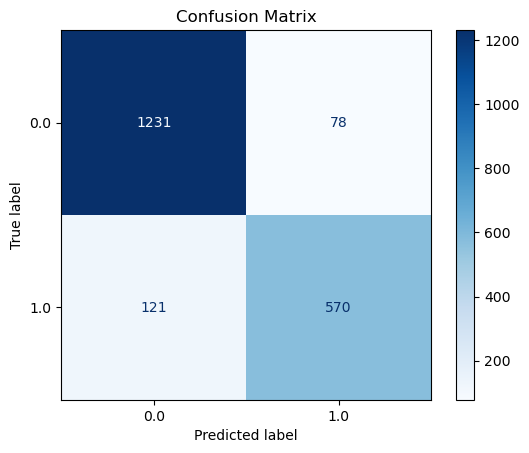

In [29]:
print("\nTarget :  Test Results_Abnormal | Model: K-Nearest Neighbour")
print("---------------------------------------------------------------")

cm = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, values_format="d", cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [30]:
print("Target :  Test Results_Abnormal | Model: K-Nearest Neighbour")
print("---------------------------------------------------------------")

print(
    classification_report(
        y_test, model.predict(x_test), target_names=["No", "Yes"], digits=6
    )
)

y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)


Target :  Test Results_Abnormal | Model: K-Nearest Neighbour
---------------------------------------------------------------
              precision    recall  f1-score   support

          No   0.910503  0.940413  0.925216      1309
         Yes   0.879630  0.824891  0.851382       691

    accuracy                       0.900500      2000
   macro avg   0.895066  0.882652  0.888299      2000
weighted avg   0.899836  0.900500  0.899706      2000



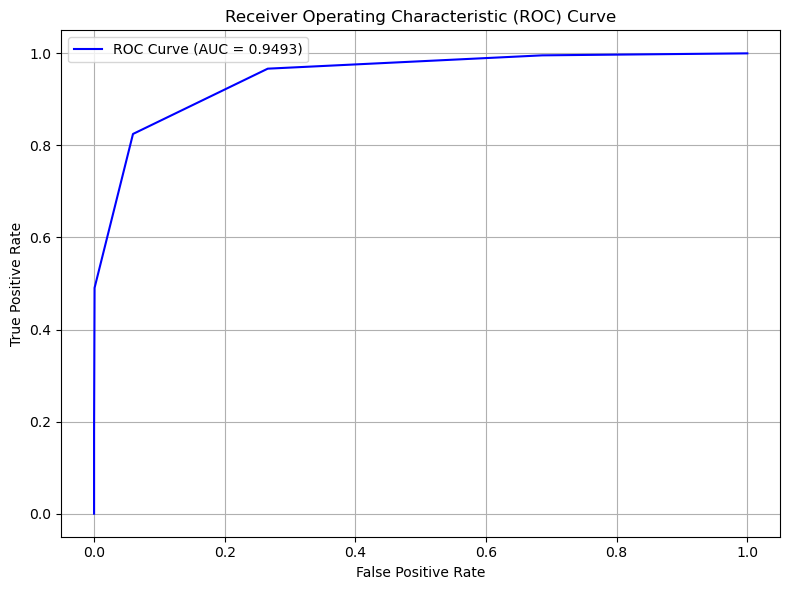

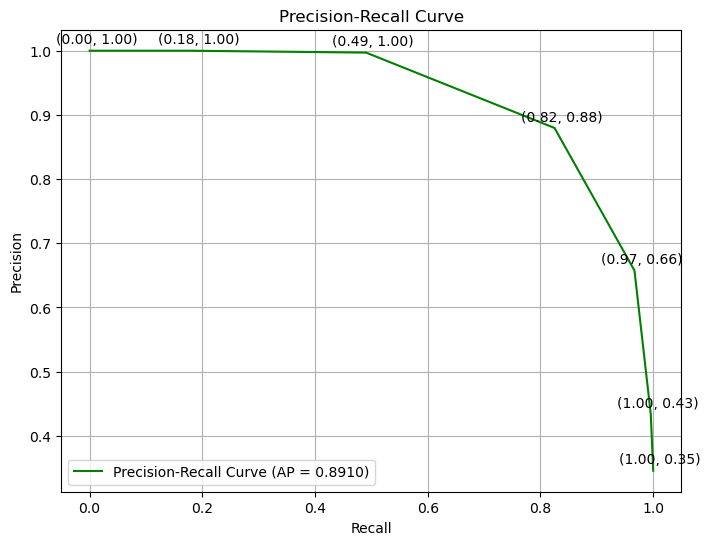

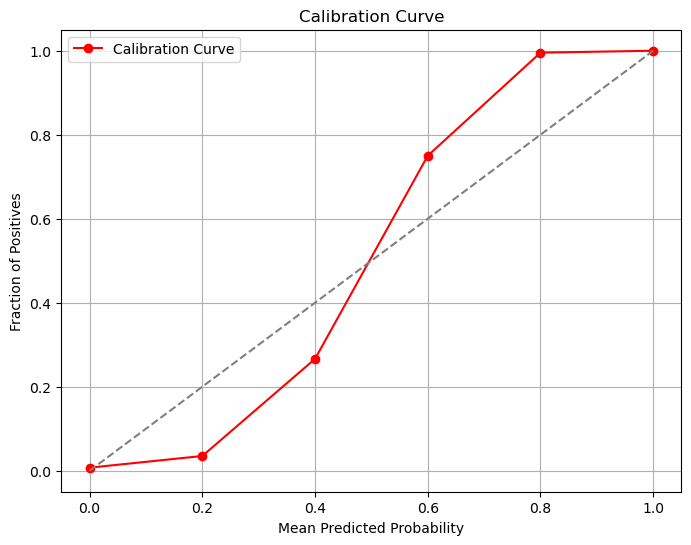

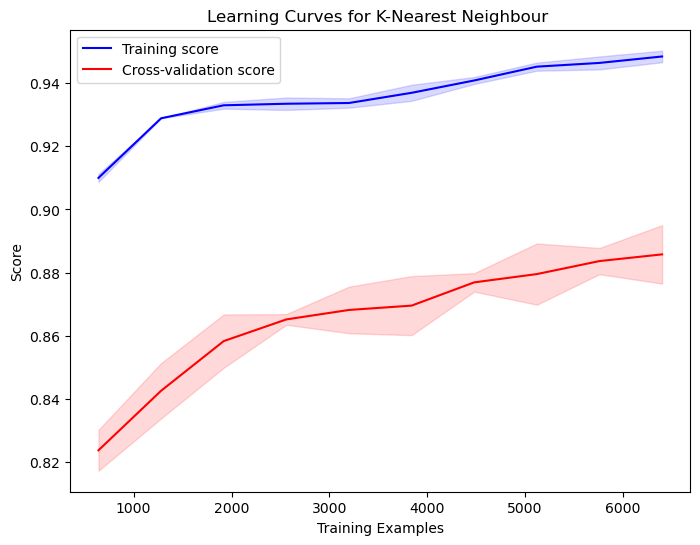

In [31]:

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:, 1])
auc_score = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Generate Precision-Recall Curve and calculate average precision score
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(x_test)[:, 1])
ap_score = average_precision_score(y_test, model.predict_proba(x_test)[:, 1])

# Calculate F-beta score
beta = 2  
f_beta_score = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# Annotate data point values on Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {ap_score:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Annotate data point values
for i in range(len(precision)):
    plt.annotate(f'({recall[i]:.2f}, {precision[i]:.2f})', (recall[i], precision[i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.show()


# Calculate Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, model.predict_proba(x_test)[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='b')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='r')
plt.title("Learning Curves for K-Nearest Neighbour ")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()


## Model: Random Forest Classifier 

### Target :  Test Results_Abnormal

In [32]:
target = "Test Results_Abnormal"
model = RandomForestClassifier(n_estimators=2, random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel: Random Forest Classifier\n")
print(f"Accuracy of Target: {target} is : ", accuracy*100,"%")




Model: Random Forest Classifier

Accuracy of Target: Test Results_Abnormal is :  92.25 %


In [33]:
# Cross Validation : Model : Random Forest Classifier
cv_score = cross_val_score(model, x_train, y_train, cv=2)

print("\nTarget :  Test Results_Abnormal | Model: Random Forest Classifier\n")
cv_score.mean()


Target :  Test Results_Abnormal | Model: Random Forest Classifier



0.883875

In [34]:
print("\nTarget :  Test Results_Abnormal | Model: Random Forest Classifier")

scores = cross_validate(model, x_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)


Target :  Test Results_Abnormal | Model: Random Forest Classifier


,fit_time,score_time,test_score,train_score
0,0.017609,0.002890,0.90125,0.968889
1,0.014957,0.002570,0.91625,0.965417
2,0.014040,0.001541,0.90250,0.963611
3,0.013533,0.001462,0.90625,0.961111
4,0.013524,0.002123,0.90750,0.975278
5,0.014242,0.001603,0.88500,0.953750
6,0.012786,0.001486,0.91000,0.969583
7,0.014348,0.001670,0.91375,0.961111
8,0.013741,0.001558,0.89000,0.961111
9,0.013541,0.001539,0.91125,0.965694



Confusion Matrix : Target :  Test Results_Abnormal | Model: Random Forest Classifier

---------------------------------------------------------------


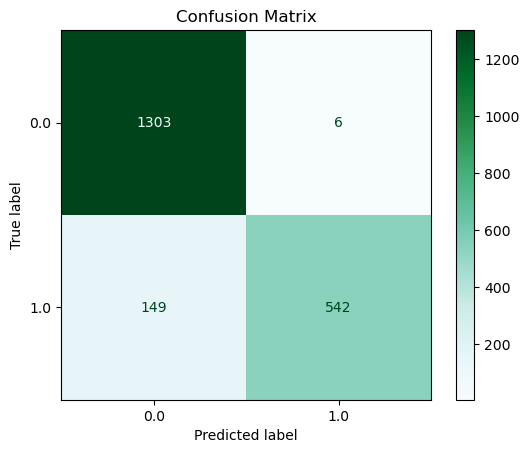

In [35]:
print("\nConfusion Matrix : Target :  Test Results_Abnormal | Model: Random Forest Classifier\n")
print("---------------------------------------------------------------")

cm = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, values_format="d", cmap= 'BuGn')
plt.title("Confusion Matrix")
plt.show()

In [36]:
print("\nTarget :  Test Results_Abnormal | Model: Random Forest Classifier\n")
print("---------------------------------------------------------------")

print(
    classification_report(
        y_test, model.predict(x_test), target_names=["No", "Yes"], digits=6
    )
)


Target :  Test Results_Abnormal | Model: Random Forest Classifier

---------------------------------------------------------------
              precision    recall  f1-score   support

          No   0.897383  0.995416  0.943861      1309
         Yes   0.989051  0.784370  0.874899       691

    accuracy                       0.922500      2000
   macro avg   0.943217  0.889893  0.909380      2000
weighted avg   0.929054  0.922500  0.920035      2000




Target :  Test Results_Abnormal | Model: Random Forest Classifier

---------------------------------------------------------------


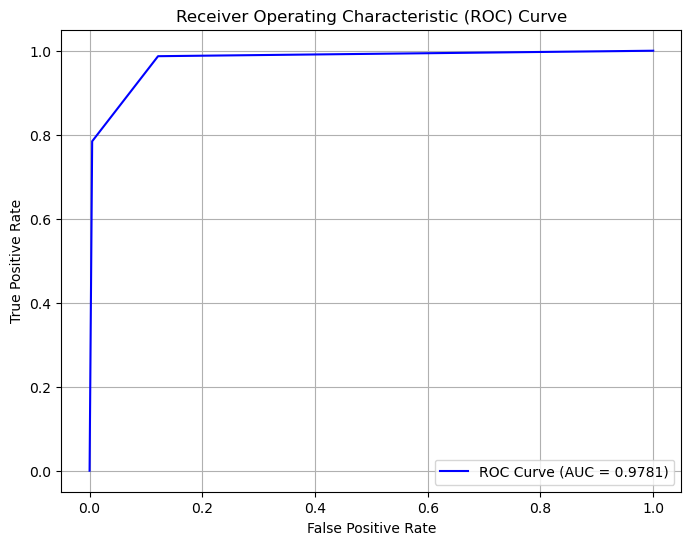

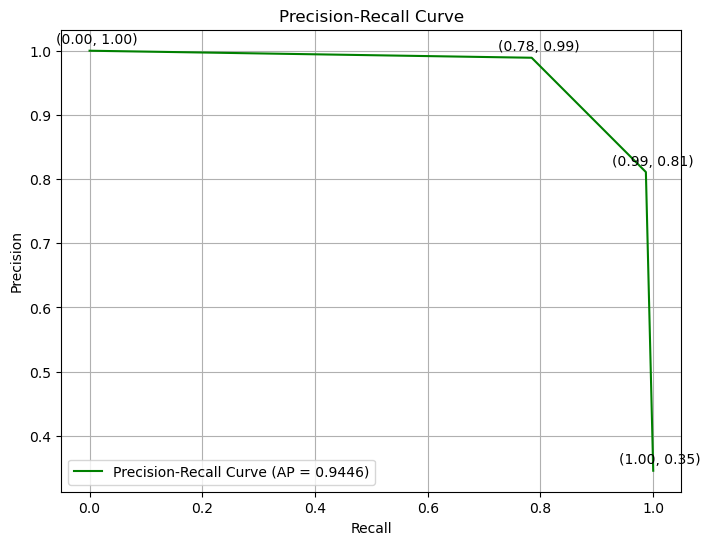

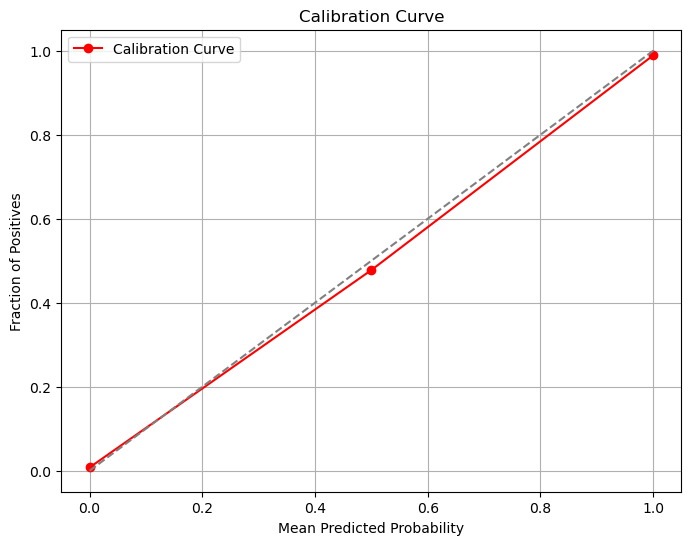

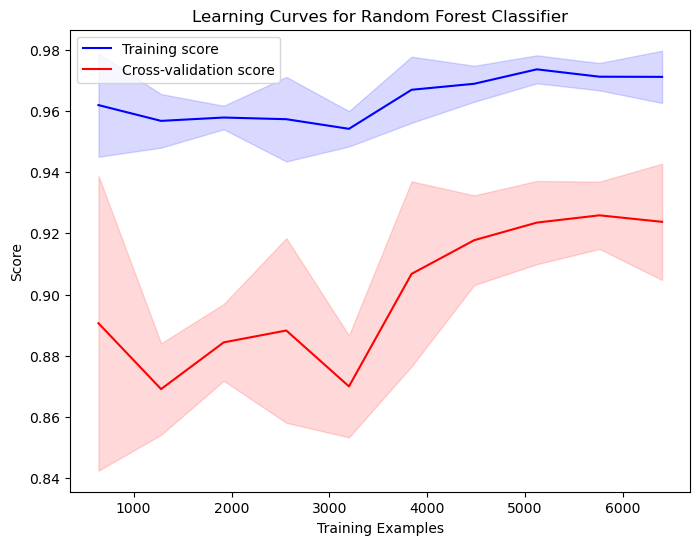

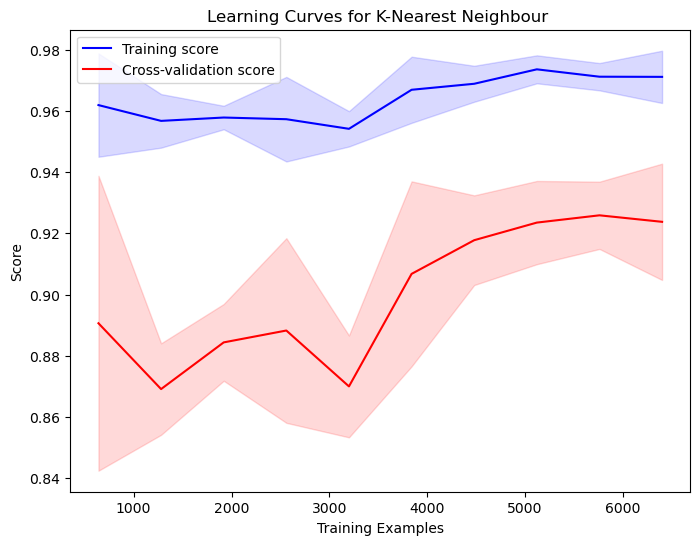

In [37]:
print("\nTarget :  Test Results_Abnormal | Model: Random Forest Classifier\n")
print("---------------------------------------------------------------")


# Generate ROC Curve and calculate AUC score
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:, 1])
auc_score = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

# Generate Precision-Recall Curve and calculate average precision score
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(x_test)[:, 1])
ap_score = average_precision_score(y_test, model.predict_proba(x_test)[:, 1])

# Calculate F-beta score
beta = 2  
f_beta_score = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# Annotate data point values on Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {ap_score:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Annotate data point values
for i in range(len(precision)):
    plt.annotate(f'({recall[i]:.2f}, {precision[i]:.2f})', (recall[i], precision[i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.show()


# Calculate Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, model.predict_proba(x_test)[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='b')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='r')
plt.title("Learning Curves for Random Forest Classifier")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()



train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='b')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='r')
plt.title("Learning Curves for K-Nearest Neighbour ")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()



#
#

####  Based on the above evaluations, Random Forest Classifier high probability of correctly classifing the classes. 
#### Hence we will be uing Random Forest Classifier for the features : Test Result_Inconclusive and Test Result_ Normal

#
#

## Target : Test Results_Inconclusive

In [38]:
#Case B : Target value: Test Results_Inconclusive

X = df3.drop(columns=["Test Results_Inconclusive"])


Y = df3["Test Results_Inconclusive"]


X

Y

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9995    0.0
9996    0.0
9997    0.0
9998    0.0
9999    0.0
Name: Test Results_Inconclusive, Length: 10000, dtype: float64

In [39]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state = 123)

shape_dict = {
    "Data portion": ["X", "y", "X_train", "y_train", "X_test", "y_test"],
    "Shape": [
        X.shape,
        Y.shape,
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape,
    ],
}

shape_df = pd.DataFrame(shape_dict)
shape_df


,Data portion,Shape
0,X,"(10000, 30)"
1,y,"(10000,)"
2,X_train,"(8000, 30)"
3,y_train,"(8000,)"
4,X_test,"(2000, 30)"
5,y_test,"(2000,)"


## Model: Random Forest Classifier 

In [40]:
target = "Test Results_Inconclusive"
model = RandomForestClassifier(n_estimators=3, random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel: Random Forest Classifier ")
print(f"Target: {target}")
print(f"Accuracy of {target} is : ", accuracy*100,"%")


Model: Random Forest Classifier 
Target: Test Results_Inconclusive
Accuracy of Test Results_Inconclusive is :  96.89999999999999 %


In [41]:
# Cross Validation : Model : Random Forest Classifier

cv_score = cross_val_score(model, x_train, y_train, cv=2)

print("\nTarget :  Test Results_Inconclusive | Model: Random Forest Classifier")
cv_score.mean()


Target :  Test Results_Inconclusive | Model: Random Forest Classifier


0.972125

In [42]:
#Model : Random Forest Classifier

scores = cross_validate(model, x_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.013265,0.001436,0.99000,0.999306
1,0.013095,0.001254,0.99625,0.999167
2,0.012747,0.001289,0.98875,0.999167
3,0.012499,0.001247,0.98750,0.998750
4,0.012448,0.001266,0.99000,0.998889
5,0.014472,0.001288,0.98875,0.997917
6,0.012449,0.001232,0.99000,0.997361
7,0.013071,0.001477,0.98875,0.999444
8,0.012832,0.001456,0.98500,0.999167
9,0.012787,0.001229,0.98875,0.999306



Target :  Test Results_Inconclusive | Model: Random Forest Classifier
---------------------------------------------------------------


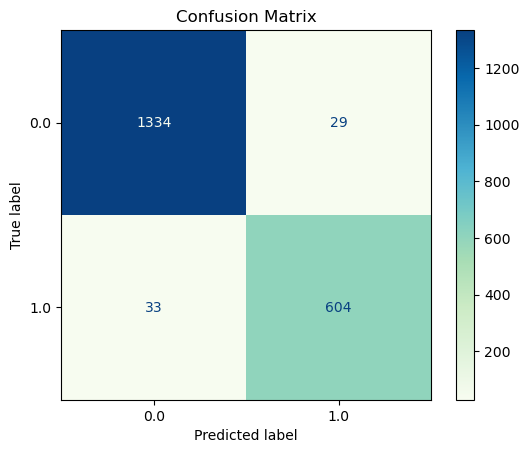

In [43]:
print("\nTarget :  Test Results_Inconclusive | Model: Random Forest Classifier")
print("---------------------------------------------------------------")


from sklearn.metrics import ConfusionMatrixDisplay  

cm = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, values_format="d", cmap='GnBu')
plt.title("Confusion Matrix")
plt.show()

In [44]:
print("\nTarget :  Test Results_Inconclusive | Model: Random Forest Classifier")
print("---------------------------------------------------------------")

print(
    classification_report(
        y_test, model.predict(x_test), target_names=["No", "Yes"], digits=6
    )
)

y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)



Target :  Test Results_Inconclusive | Model: Random Forest Classifier
---------------------------------------------------------------
              precision    recall  f1-score   support

          No   0.975860  0.978723  0.977289      1363
         Yes   0.954186  0.948195  0.951181       637

    accuracy                       0.969000      2000
   macro avg   0.965023  0.963459  0.964235      2000
weighted avg   0.968957  0.969000  0.968974      2000



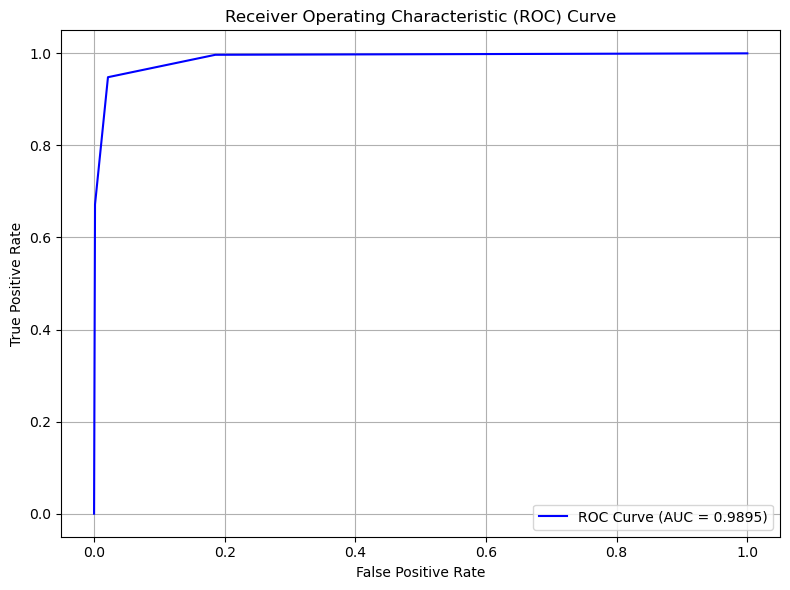

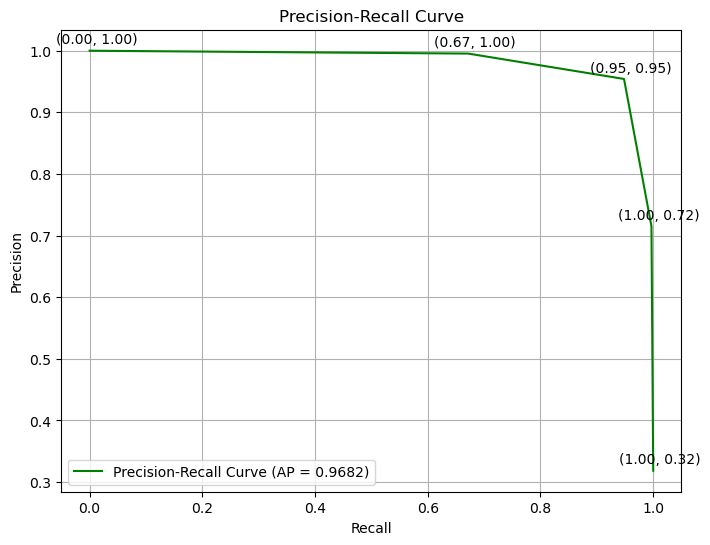

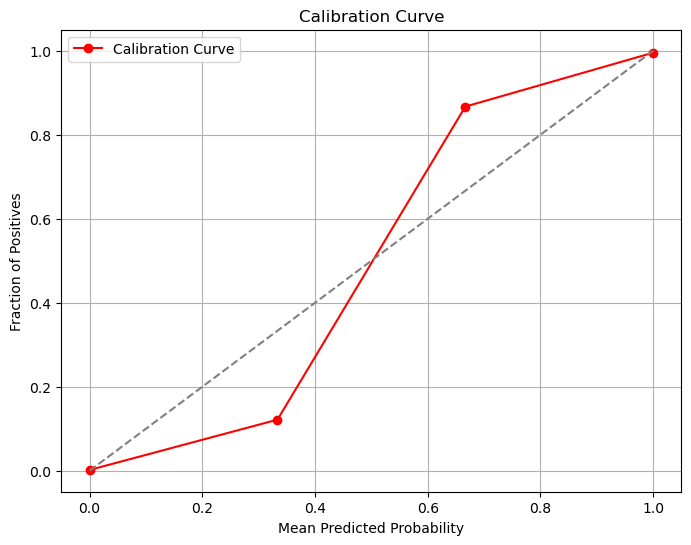

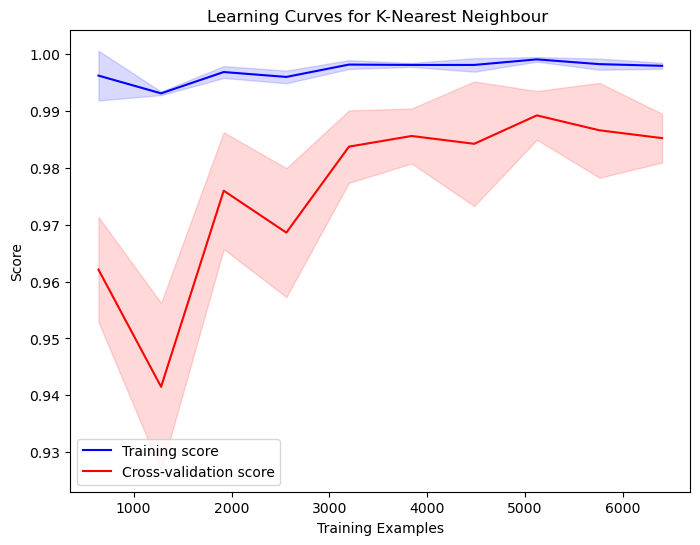

In [45]:

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:, 1])
auc_score = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Generate Precision-Recall Curve and calculate average precision score
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(x_test)[:, 1])
ap_score = average_precision_score(y_test, model.predict_proba(x_test)[:, 1])

# Calculate F-beta score
beta = 2  
f_beta_score = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# Annotate data point values on Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {ap_score:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Annotate data point values
for i in range(len(precision)):
    plt.annotate(f'({recall[i]:.2f}, {precision[i]:.2f})', (recall[i], precision[i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.show()


# Calculate Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, model.predict_proba(x_test)[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()


train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='b')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='r')
plt.title("Learning Curves for K-Nearest Neighbour ")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()



## Target : Test Results_Normal

In [46]:
X = df3.drop(columns=["Test Results_Normal"])


Y = df3["Test Results_Normal"]


X

Y

0       0.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
9995    0.0
9996    1.0
9997    1.0
9998    1.0
9999    0.0
Name: Test Results_Normal, Length: 10000, dtype: float64

In [47]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state = 123)

shape_dict = {
    "Data portion": ["X", "y", "X_train", "y_train", "X_test", "y_test"],
    "Shape": [
        X.shape,
        Y.shape,
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape,
    ],
}

shape_df = pd.DataFrame(shape_dict)
shape_df


,Data portion,Shape
0,X,"(10000, 30)"
1,y,"(10000,)"
2,X_train,"(8000, 30)"
3,y_train,"(8000,)"
4,X_test,"(2000, 30)"
5,y_test,"(2000,)"


## Model: Random Forest Classifier 

In [48]:
target = "Test Results_Normal"
model = RandomForestClassifier(n_estimators=3, random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nModel: Random Forest Classifier ")
print(f"Target: {target}")
print(f"Accuracy of {target} is : ", accuracy*100,"%")


Model: Random Forest Classifier 
Target: Test Results_Normal
Accuracy of Test Results_Normal is :  97.95 %


In [49]:
# Cross Validation : Model : Random Forest Classifier

cv_score = cross_val_score(model, x_train, y_train, cv=2)

print("\nTarget : Test Results_Normal | Model: Random Forest Classifier")
cv_score.mean()


Target : Test Results_Normal | Model: Random Forest Classifier


0.981875

In [50]:
#Model : Random Forest Classifier

scores = cross_validate(model, x_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.013361,0.001348,0.98500,0.998750
1,0.014314,0.001388,0.97500,0.996389
2,0.013400,0.001248,0.99125,0.998611
3,0.012883,0.001280,0.98625,0.996944
4,0.012473,0.001234,0.99250,0.999583
5,0.013361,0.001284,0.98125,0.996528
6,0.011688,0.001194,0.99875,0.999583
7,0.012809,0.001254,0.98500,0.998056
8,0.011785,0.001251,0.99500,0.998750
9,0.012653,0.001215,0.99375,0.999167



Target :  Test Results_Normal | Model: Random Forest Classifier
---------------------------------------------------------------


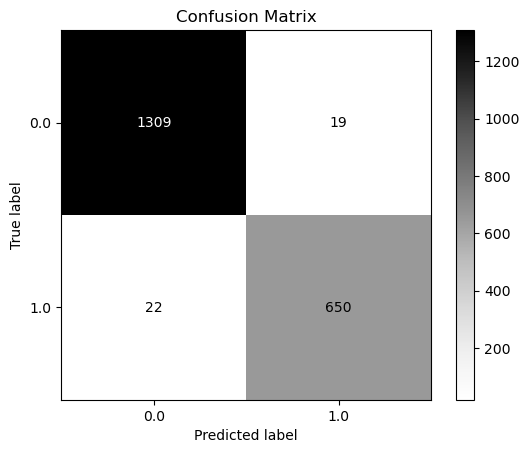

In [51]:
print("\nTarget :  Test Results_Normal | Model: Random Forest Classifier")
print("---------------------------------------------------------------")



cm = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, values_format="d", cmap= 'Greys')
plt.title("Confusion Matrix")
plt.show()

In [52]:
print("\nTarget :  Test Results_Normal | Model: Random Forest Classifier")
print("---------------------------------------------------------------")

print(
    classification_report(
        y_test, model.predict(x_test), target_names=["No", "Yes"], digits=6
    )
)

y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)



Target :  Test Results_Normal | Model: Random Forest Classifier
---------------------------------------------------------------
              precision    recall  f1-score   support

          No   0.983471  0.985693  0.984581      1328
         Yes   0.971599  0.967262  0.969426       672

    accuracy                       0.979500      2000
   macro avg   0.977535  0.976477  0.977003      2000
weighted avg   0.979482  0.979500  0.979489      2000



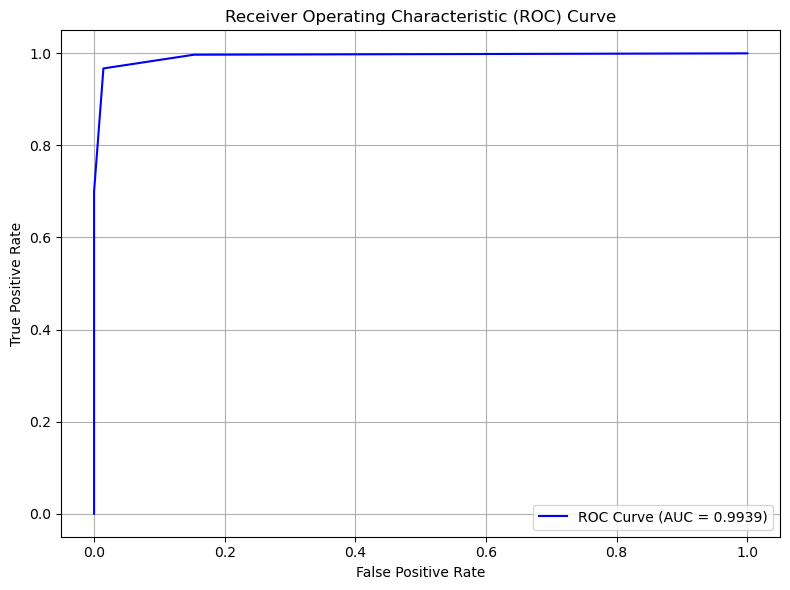

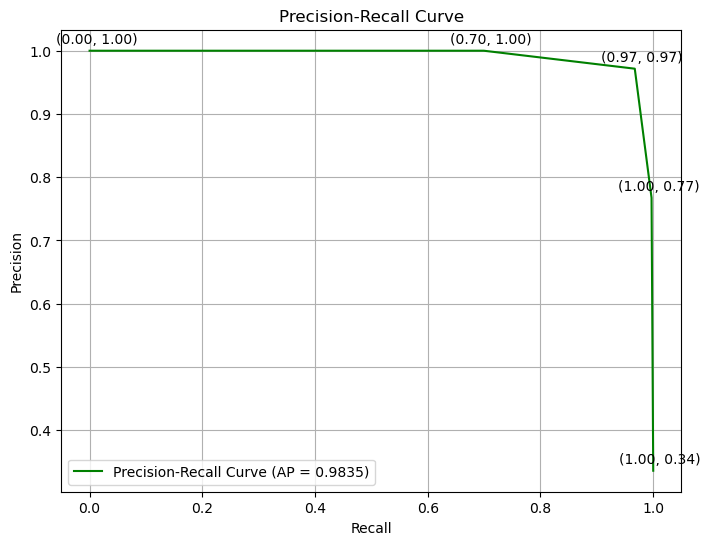

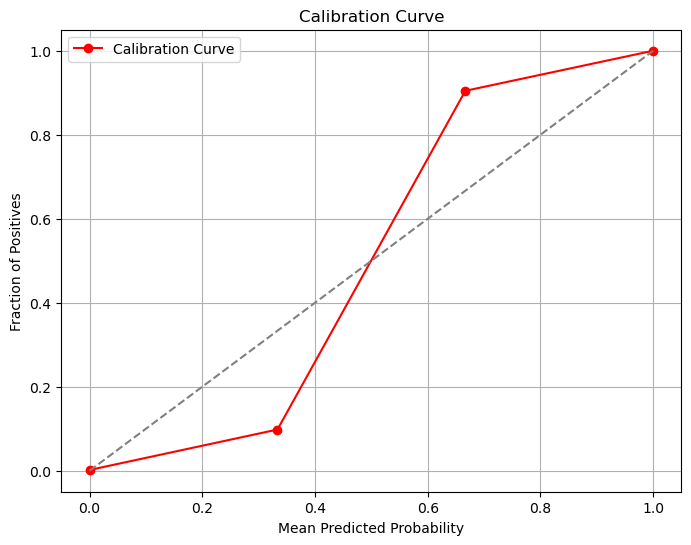

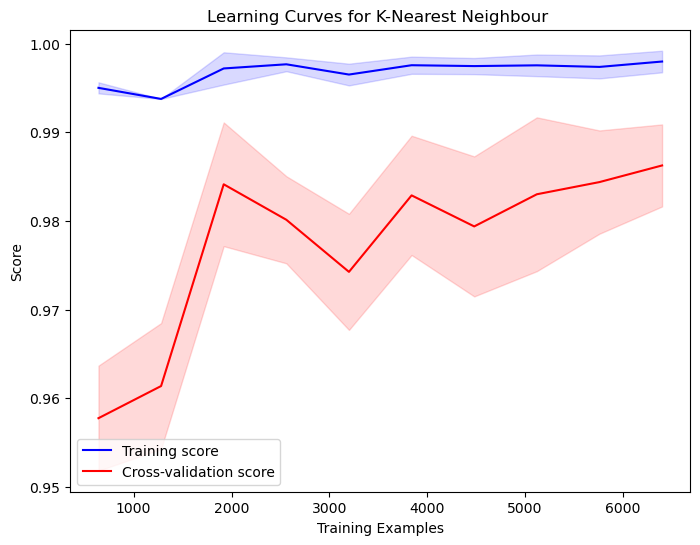

In [53]:

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:, 1])
auc_score = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Generate Precision-Recall Curve and calculate average precision score
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(x_test)[:, 1])
ap_score = average_precision_score(y_test, model.predict_proba(x_test)[:, 1])

# Calculate F-beta score
beta = 2  
f_beta_score = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

# Annotate data point values on Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {ap_score:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Annotate data point values
for i in range(len(precision)):
    plt.annotate(f'({recall[i]:.2f}, {precision[i]:.2f})', (recall[i], precision[i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.show()


# Calculate Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, model.predict_proba(x_test)[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()


train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='b')
plt.plot(train_sizes, test_mean, label='Cross-validation score', color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='r')
plt.title("Learning Curves for K-Nearest Neighbour ")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.show()



## --- Selecting Target ----

In [54]:
X = df3.drop(columns=["Medical Condition_Asthma"])


Y = df3["Medical Condition_Asthma"]


X

Y

0       0.0
1       1.0
2       0.0
3       1.0
4       0.0
       ... 
9995    0.0
9996    0.0
9997    0.0
9998    0.0
9999    0.0
Name: Medical Condition_Asthma, Length: 10000, dtype: float64

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=123)
shape_dict = {
    "Data portion": ["X", "y", "X_train", "y_train", "X_test", "y_test"],
    "Shape": [
        X.shape,
        Y.shape,
        x_train.shape,
        y_train.shape,
        x_test.shape,
        y_test.shape,
    ],
}

shape_df = pd.DataFrame(shape_dict)
shape_df


,Data portion,Shape
0,X,"(10000, 30)"
1,y,"(10000,)"
2,X_train,"(8000, 30)"
3,y_train,"(8000,)"
4,X_test,"(2000, 30)"
5,y_test,"(2000,)"


In [56]:

# Step 2: Train the Model
model = RandomForestClassifier(n_estimators=5, random_state=123)
model.fit(x_train, y_train)


# Step 3: Predict Probabilities
probabilities = model.predict_proba(x_test)

# Step 4: Make Predictions
predictions = model.predict(x_test)

print(predictions)




[0. 0. 0. ... 0. 1. 1.]
Accuracy: 1.0
Predicted Probabilities: [[0.8 0.2]]


In [57]:

cv_score = cross_val_score(model, x_train, y_train, cv=2)
cv_score.mean()

1.0

In [58]:

scores = cross_validate(model, x_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.020706,0.001508,1.0,1.0
1,0.017488,0.001313,1.0,1.0
2,0.023386,0.001664,1.0,1.0
3,0.019209,0.001838,1.0,1.0
4,0.029571,0.001897,1.0,1.0
5,0.021025,0.001409,1.0,1.0
6,0.018280,0.001378,1.0,1.0
7,0.017946,0.001316,1.0,1.0
8,0.017072,0.001291,1.0,1.0
9,0.017562,0.001313,1.0,1.0


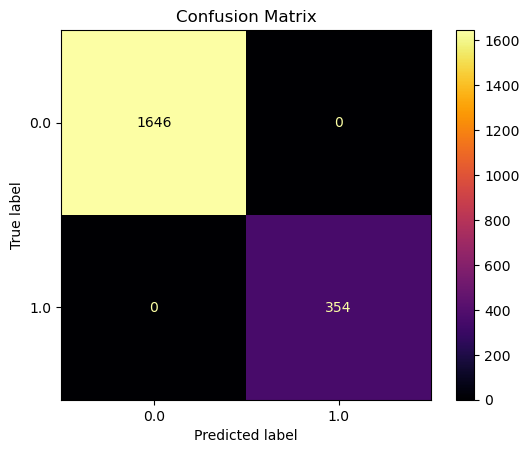

In [59]:
cm = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, values_format="d", cmap='inferno')
plt.title('Confusion Matrix')
plt.show()


In [60]:

print(classification_report(y_test, model.predict(x_test), target_names=["No", "Yes"], digits=6))

y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)


              precision    recall  f1-score   support

          No   1.000000  1.000000  1.000000      1646
         Yes   1.000000  1.000000  1.000000       354

    accuracy                       1.000000      2000
   macro avg   1.000000  1.000000  1.000000      2000
weighted avg   1.000000  1.000000  1.000000      2000



In [65]:

# Assuming x_train is your training data
new_data = np.zeros((1, x_train.shape[1]))

# Assigning values to new_data
new_data[0, :2] = [1.5084648157772200, 0.8512494612180910]  # Age and Billing Amount
# Assigning the remaining values to match the transformed format
new_data[0, 2:16] = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]  # Medical Condition and Blood Type
new_data[0, 16:21] = [1, 0, 0, 0, 0]  # Medication
new_data[0, 21:24] = [0, 1, 0]  # Test Results
new_data[0, 24:29] = [0, 0, 0, 1, 0]  # Insurance Provider
new_data[0, 29] = 1  # Gender
new_data[0, 29] = 2  # Admission Type

In [66]:


# Step 5: Evaluate the Model (Optional)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

predicted_probabilities = model.predict_proba(new_data)
print("Predicted Probabilities:", predicted_probabilities)

Accuracy: 1.0
Predicted Probabilities: [[0.8 0.2]]
